# 02. Returns Analysis

## Research Question

What are the statistical and financial characteristics of Bitcoin daily returns, and why are returns preferred over raw prices in quantitative finance?

## Why This Matters

Financial assets are purchased because of the returns they generate, not because of their absolute prices.

Returns allow meaningful comparison across different assets, different time periods, and different market environments.

Virtually every quantitative model—including CAPM, Fama-French, Black-Litterman, GARCH, stochastic volatility models, and machine learning forecasting models—is built using returns rather than prices.

In [1]:
# ==========================================
# Research Configuration
# ==========================================

TICKER = "BTC-USD"

START_DATE = "2020-01-01"
END_DATE = "2026-06-20"

INTERVAL = "1d"

AUTO_ADJUST = True

REFRESH_CACHE = True

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

# We will load Bitcoins data from the our own Crypto alpha research lab CARL API

from crypto_alpha_lab.data.storage import load_prices

# APRL
from asset_pricing_lab.returns import (
    arithmetic_returns,
    cumulative_returns,
    log_returns,
)

In [22]:
btc = load_prices(
    ticker=TICKER,
    start=START_DATE,
    end=END_DATE,
    interval=INTERVAL,
    auto_adjust=AUTO_ADJUST,
    refresh=REFRESH_CACHE,
)

In [23]:
btc["Close"].head()

Date
2020-01-01    7200.174316
2020-01-02    6985.470215
2020-01-03    7344.884277
2020-01-04    7410.656738
2020-01-05    7411.317383
Name: Close, dtype: float64

In [24]:
btc["Close"].tail()

Date
2026-06-15    66289.500000
2026-06-16    65600.640625
2026-06-17    64418.445312
2026-06-18    62896.472656
2026-06-19    63540.835938
Name: Close, dtype: float64

In [25]:
# Calculating simple arithmetic returns from Bitcoins closed prices

simple_returns = arithmetic_returns(btc["Close"])

In [26]:
# To check that our arithmetic returns is in a pandas series

simple_returns = arithmetic_returns(btc["Close"])

type(simple_returns)

pandas.Series

In [14]:
simple_returns.head()

Date
2020-01-02   -0.029819
2020-01-03    0.051452
2020-01-04    0.008955
2020-01-05    0.000089
2020-01-06    0.048291
Name: Close, dtype: float64

In [15]:
simple_returns.describe()

count    2361.000000
mean        0.001429
std         0.031547
min        -0.371695
25%        -0.012832
50%         0.000316
75%         0.015037
max         0.187465
Name: Close, dtype: float64

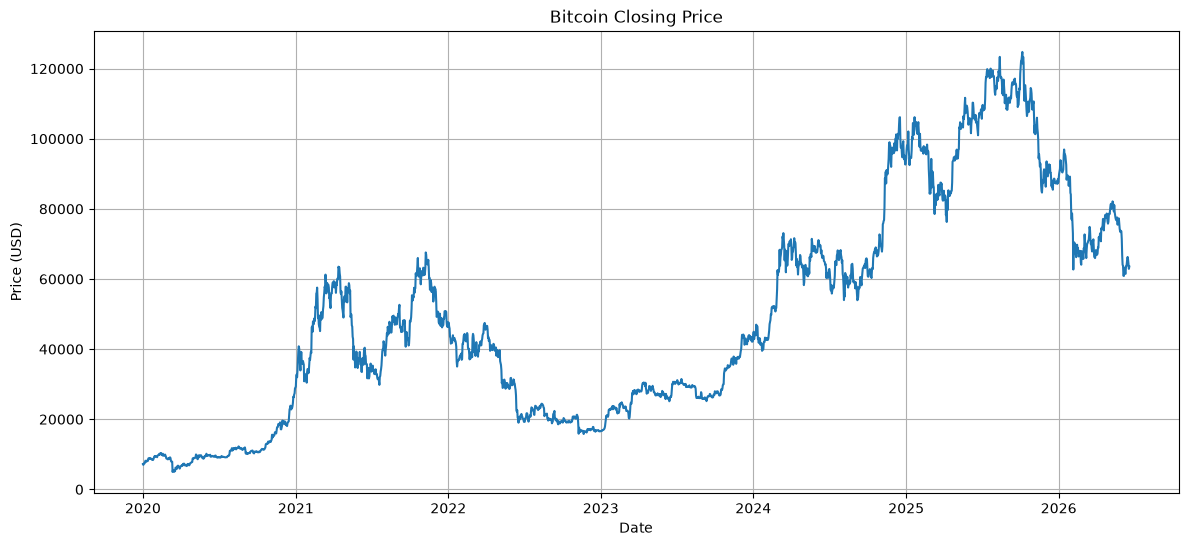

In [27]:
# Plotting Bitcoins daily  closed price movement

plt.figure(figsize=(14, 6))

plt.plot(btc.index, btc["Close"], linewidth=1.5)

plt.title("Bitcoin Closing Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")

plt.grid(True)

plt.show()

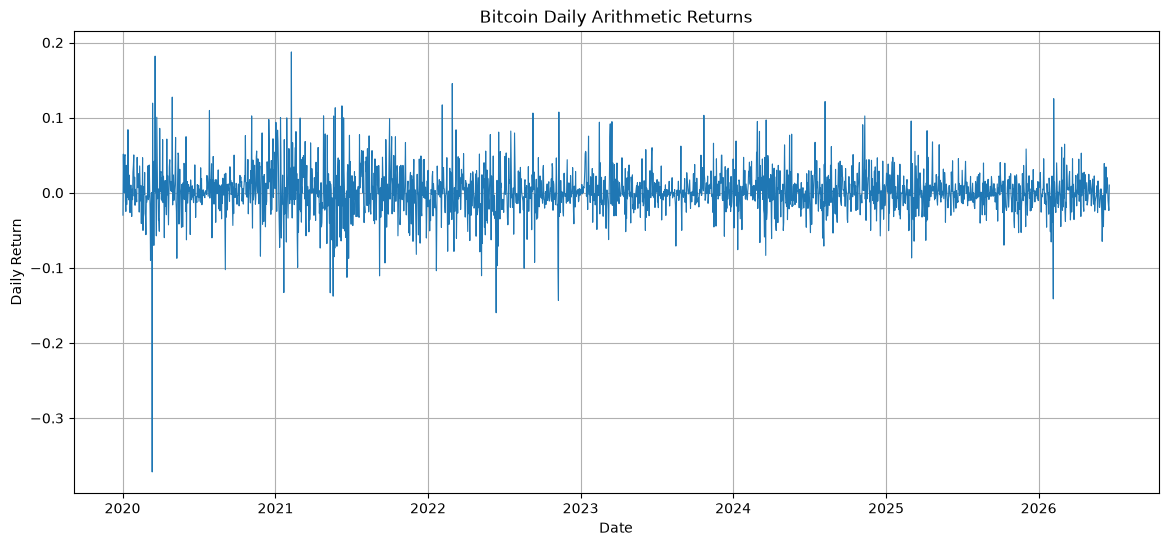

In [28]:
# Plotting Bitcoins daily arithmetic returns movement
plt.figure(figsize=(14, 6))

plt.plot(simple_returns.index, simple_returns, linewidth=0.8)

plt.title("Bitcoin Daily Arithmetic Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.grid(True)

plt.show()

### Compare the Two Figures

Now place the two charts side by side mentally.

Price chart

Strong upward trend.
Large changes in scale.
Values always positive.
Difficult to compare across time.

Return chart

Oscillates around zero.
Positive and negative observations.
Similar scale throughout most of the sample.
Easier to analyze statistically.

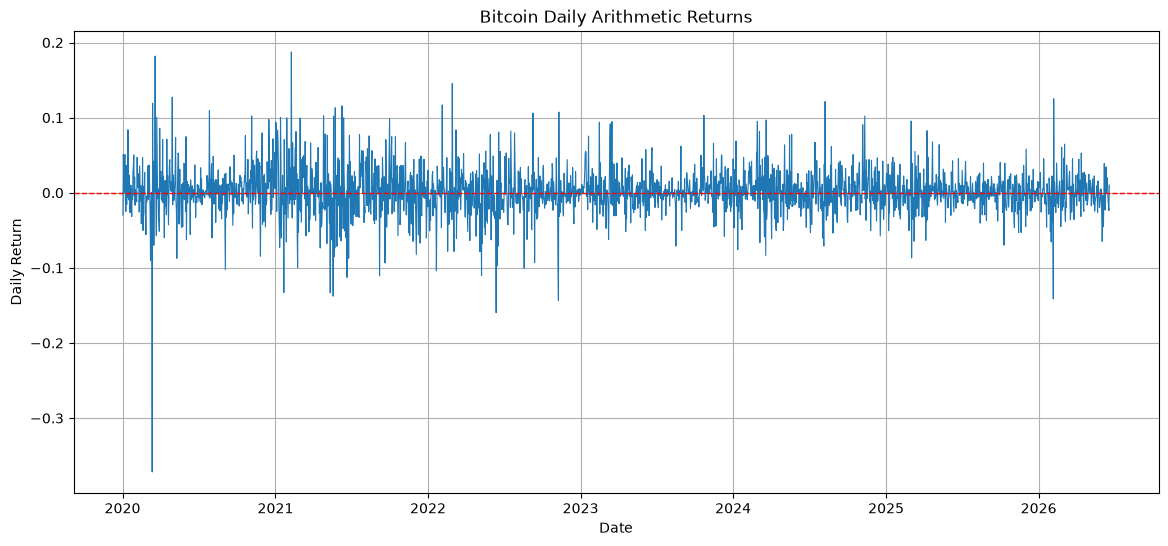

In [30]:

plt.figure(figsize=(14, 6))

plt.plot(simple_returns.index, simple_returns, linewidth=0.8)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=1,
)

plt.title("Bitcoin Daily Arithmetic Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.grid(True)

plt.show()

### Why Add the Zero Line?

The dashed line represents no daily gain or loss.

Observations:

Above the line → positive daily returns.\
Below the line → negative daily returns.\
Near the line → relatively quiet trading days.

This simple addition makes it much easier to identify market behavior.

### Statistical Interpretation

The return series is much closer to a stationary process because:

its mean is relatively stable,
its scale is more consistent,
there is no persistent upward trend.

Notice I said closer to stationary—not perfectly stationary. We'll test this formally in later notebooks.

0.05   → +5% return

-0.03  → -3% return

0.00   → No change

0.12   → +12% return

## Key Findings

- Bitcoin prices are non-stationary and trend over time.
- Daily returns fluctuate around a stable mean.
- Returns contain both positive and negative observations.
- Volatility clustering is visible in the return series.
- Returns provide a better foundation for quantitative modeling than prices.

## Research Limitations

- The analysis is exploratory and descriptive.
- No formal statistical tests were performed.
- Results depend on the selected sample period.
- Historical returns do not guarantee future performance.

## Next Notebook

In **Notebook 03**, we will examine the probability distribution of Bitcoin returns using histograms, density plots, skewness, kurtosis, and normality comparisons.